In [16]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def _message_figure(text: str, w: float = 8, h: float = 3):
    fig, ax = plt.subplots(figsize=(w, h))
    ax.axis("off")
    ax.text(0.5, 0.5, text, ha="center", va="center", fontsize=10)
    return fig

In [17]:
def render_kpi_table(
    dataset: pd.DataFrame,
    group_cols=None,              # ví dụ ["Month","LOB"] hoặc ["_PST.Month","LOB"] hoặc ["Month","Supervisor Name"]
    include_extra=False,          # True để hiển thị DUET (trung bình) và so target DUET
    decimals=1,                   # số chữ số thập phân hiển thị
    target_df: pd.DataFrame | None = None,  # BẢNG TARGET (Eff_Date, LOB, Metric, Target, Weight)
    target_date_col: str = "Eff_Date",      # tên cột hiệu lực trong target_df
):
    if dataset is None or dataset.empty:
        return _message_figure("Không có dữ liệu sau bộ lọc.")

    # ---- 1) Chuẩn hoá cột đặc biệt & alias cho group_cols ----
    conv_candidates = ["_conver_unique", "Conversation Id", "Conversation_Id", "ConversationID"]
    conv_col = next((c for c in conv_candidates if c in dataset.columns), None)

    alias_map = {"_PST.Month": "Month", "_PST.Date": "PST_Date"}

    df = dataset.copy()
    if conv_col is None:
        return _message_figure("Thiếu cột Conversation Id / _conver_unique.")

    # alias _PST.Month/_PST.Date
    if "_PST.Month" in df.columns and "Month" not in df.columns:
        df = df.rename(columns={"_PST.Month": "Month"})
    if "_PST.Date" in df.columns and "PST_Date" not in df.columns:
        df = df.rename(columns={"_PST.Date": "PST_Date"})
    # alias conversation
    df = df.rename(columns={conv_col: "Conv"})

    # parse ngày nếu có
    if "PST_Date" in df.columns:
        with pd.option_context('mode.chained_assignment', None):
            df["PST_Date"] = pd.to_datetime(df["PST_Date"], errors="coerce")

    # group_cols mặc định
    if group_cols is None:
        default = []
        if "Month" in df.columns: default.append("Month")
        if "LOB"   in df.columns: default.append("LOB")
        group_cols = default if default else [c for c in df.columns if df[c].dtype == "O"][:1]

    # áp alias cho group_cols (nếu user truyền "_PST.Month"/"_PST.Date")
    group_cols = [alias_map.get(c, c) for c in group_cols]

    # kiểm tra tồn tại group cols
    missing_gc = [c for c in group_cols if c not in df.columns]
    if missing_gc:
        return _message_figure("Thiếu cột group by: " + ", ".join(missing_gc))

    # ép kiểu số
    num_cols = ["Handle Time (Sum)", "_lc", "_aob", "CCR72",
                "_survey", "_promoter", "_detractor", "_neutral",
                "Re_Direct", "Exceed Chat", "DUET", "delight", "usability", "ease", "trust"]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if df.empty:
        return _message_figure("Không có dữ liệu hợp lệ (sau ép kiểu).")

    # ---- 2) Cấp hội thoại (để tính AHT/LC/AoB/flags đúng kiểu DAX) ----
    by_conv = group_cols + ["Conv"]
    agg_dict = {
        "Handle Time (Sum)": ("ht_per_conv", "max"),
        "_lc":               ("lc_per_conv", "mean"),
        "_aob":              ("aob_per_conv", "mean"),
        "Re_Direct":         ("redir_per_conv", "max"),
        "Exceed Chat":       ("excd_per_conv", "max"),
    }
    use_cols = [k for k in agg_dict if k in df.columns]
    if use_cols:
        conv = (df.groupby(by_conv)
                  .agg(**{agg_dict[k][0]: (k, agg_dict[k][1]) for k in use_cols})
                  .reset_index())
    else:
        conv = df[by_conv].drop_duplicates().copy()

    # ---- 3) Tổng hợp theo group_cols ----
    g = group_cols
    chats = conv.groupby(g)["Conv"].nunique().rename("Chats")
    aht = conv.groupby(g)["ht_per_conv"].mean().rename("AHT")           if "ht_per_conv"  in conv else None
    lc  = conv.groupby(g)["lc_per_conv"].mean().rename("LC %")          if "lc_per_conv"  in conv else None
    aob = conv.groupby(g)["aob_per_conv"].mean().rename("AoB %")        if "aob_per_conv" in conv else None

    # FUP_72 theo DAX: mean theo dòng (không dedup)
    fup_rows = df.groupby(g)["CCR72"].mean().rename("FUP_72 %")         if "CCR72" in df else None
    rr       = (1 - fup_rows).rename("RR %")                             if fup_rows is not None else None

    redr = conv.groupby(g)["redir_per_conv"].mean().rename("Re-direct %")   if "redir_per_conv" in conv else None
    excd = conv.groupby(g)["excd_per_conv"].mean().rename("Exceed Chat %")  if "excd_per_conv"  in conv else None

    # --- ĐẾM & TỶ LỆ NPS theo DÒNG ---
    sum_cols = [c for c in ["_survey","_promoter","_detractor","_neutral"] if c in df]  # <-- KHÔNG còn DUET ở đây
    sums = df.groupby(g)[sum_cols].sum(min_count=1) if sum_cols else pd.DataFrame(index=chats.index)
    sums = sums.rename(columns={"_survey":"Survey","_promoter":"Promoter","_detractor":"Detractor","_neutral":"Neutral"})
    nps_pct = ((sums["Promoter"] - sums["Detractor"]) / sums["Survey"] * 100).rename("NPS %") \
              if {"Promoter","Detractor","Survey"}.issubset(sums.columns) else None

    # --- DUET & các chỉ số cảm nhận: LẤY TRUNG BÌNH ---
    extra_list = [c for c in ["DUET","delight","usability","ease","trust"] if c in df.columns]
    extras_mean = df.groupby(g)[extra_list].mean() if extra_list else pd.DataFrame(index=chats.index)

    # ---- Hợp nhất các chỉ số ----
    parts = [chats]
    for s in (aht, lc, aob, fup_rows, rr, nps_pct, redr, excd):
        if s is not None: parts.append(s)
    for c in ["Survey","Promoter","Detractor","Neutral"]:
        if c in sums.columns: parts.append(sums[c])

    # Thêm DUET trung bình nếu cần (nhân 100 để hiển thị & so target theo %)
    if include_extra and "DUET" in extras_mean.columns:
        parts.append((extras_mean["DUET"]).rename("DUET"))

    out = pd.concat(parts, axis=1).reset_index().sort_values(group_cols).reset_index(drop=True)
    if out.empty:
        return _message_figure("Groupby trống.")

    # ---- (3b) AnchorDate để so với Target Eff_Date (as-of) ----
    if "AnchorDate" not in out.columns:
        out["AnchorDate"] = pd.NaT
    if "PST_Date" in df.columns:
        grp_date = (df.groupby(group_cols)["PST_Date"]
                      .max()
                      .reset_index()
                      .rename(columns={"PST_Date": "AnchorDate"}))
        out = out.drop(columns=["AnchorDate"]).merge(grp_date, on=group_cols, how="left")

    # ---- 4) Định dạng 1 chữ số thập phân ----
    pct_cols = [c for c in ["LC %","AoB %","FUP_72 %","RR %","NPS %","Re-direct %","Exceed Chat %","DUET"] if c in out.columns]
    numeric_cols = [c for c in out.columns if c not in group_cols + ["AnchorDate"]]
    for c in numeric_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").round(decimals)

    show = out.copy()
    for c in pct_cols:
        show[c] = show[c].map(lambda v: "" if pd.isna(v) else f"{v:.{decimals}f}%")
    for c in [x for x in numeric_cols if x not in pct_cols]:
        show[c] = show[c].map(lambda v: "" if pd.isna(v) else f"{v:,.{decimals}f}")

    # ---- 5) Heat colors (NPS ↑ tốt; AHT/LC ↓ tốt) ----
    cmap = plt.cm.RdYlGn
    col_norm = {}
    if "NPS %" in out: col_norm["NPS %"] = ((out["NPS %"].astype(float) + 100) / 200).clip(0,1)
    if "LC %"  in out:
        mx = out["LC %"].astype(float).max()
        col_norm["LC %"] = 1 - (out["LC %"].astype(float) / (mx if (mx and mx>0) else 1.0))
    if "AHT" in out:
        mx = out["AHT"].astype(float).max()
        col_norm["AHT"] = 1 - (out["AHT"].astype(float) / (mx if (mx and mx>0) else 1.0))

    # ---- 6) So sánh TARGET theo LOB + Eff_Date <= AnchorDate ----
    two_color = {}  # {metric_column: Series[bool]}
    GREEN, RED = "#c9f2cf", "#f7c7c7"

    if target_df is not None and not target_df.empty:
        tdf = target_df.copy()
        if target_date_col not in tdf.columns:
            tdf[target_date_col] = pd.NaT
        tdf[target_date_col] = pd.to_datetime(tdf[target_date_col], errors="coerce")
        tdf["Metric_norm"] = tdf["Metric"].astype(str).str.upper().str.strip()
        tdf["Target"] = pd.to_numeric(tdf["Target"], errors="coerce")

        # ánh xạ metric -> (cột trong out, hướng so sánh, hệ số convert target)
        metric_map = {
            "NPS":  ("NPS %", "high", 100.0),
            "LC":   ("LC %",  "low",  100.0),
            "AHT":  ("AHT",   "low",    1.0),
            "DUET": ("DUET",  "high", 1.0),
        }

        def asof_target_for(metric_code: str) -> pd.Series:
            col_out, _, scale = metric_map[metric_code]
            if col_out not in out.columns:
                return pd.Series(index=out.index, dtype=float)

            rows = tdf[tdf["Metric_norm"] == metric_code].dropna(subset=[target_date_col])
            if rows.empty:
                return pd.Series(index=out.index, dtype=float)

            # chuẩn bị điểm mốc thời gian để chọn target "as of"
            if "AnchorDate" in out.columns:
                left = out[["AnchorDate"]].copy()
            else:
                left = pd.DataFrame({"AnchorDate": pd.NaT}, index=out.index)
            left["__idx__"] = np.arange(len(out))
            max_date = pd.Timestamp("2262-04-11")  # sentinel: khi AnchorDate NaT → lấy target mới nhất
            left["AnchorDate_filled"] = left["AnchorDate"].fillna(max_date)

            if "LOB" in out.columns and "LOB" in rows.columns:
                targets = pd.Series(index=out.index, dtype=float)
                for lob, subL in left.join(out["LOB"]).groupby("LOB"):
                    L = subL.sort_values("AnchorDate_filled")
                    R = rows[rows["LOB"] == lob].sort_values(target_date_col)
                    if R.empty:
                        continue
                    m = pd.merge_asof(
                        L[["AnchorDate_filled","__idx__"]],
                        R[[target_date_col,"Target"]],
                        left_on="AnchorDate_filled",
                        right_on=target_date_col,
                        direction="backward",
                    )
                    targets.loc[L["__idx__"].values] = m["Target"].values
                return pd.to_numeric(targets, errors="coerce") * scale
            else:
                L = left.sort_values("AnchorDate_filled")
                R = rows.sort_values(target_date_col)
                m = pd.merge_asof(
                    L[["AnchorDate_filled","__idx__"]],
                    R[[target_date_col,"Target"]],
                    left_on="AnchorDate_filled",
                    right_on=target_date_col,
                    direction="backward",
                ).sort_values("__idx__")
                return pd.to_numeric(m["Target"], errors="coerce") * scale

        for metric_code, (col_out, direction, scale) in metric_map.items():
            if col_out in out.columns:
                tgt = asof_target_for(metric_code)  # Series align với index out
                vals = pd.to_numeric(out[col_out], errors="coerce")
                if direction == "high":
                    two_color[col_out] = vals >= tgt
                else:
                    two_color[col_out] = vals <= tgt

    # ---- 7) Vẽ bảng — phân bổ chiều rộng cột động ----
    metric_cols = [
        "Chats","AHT","LC %","AoB %","FUP_72 %","RR %","NPS %",
        "Survey","Promoter","Detractor","Neutral","Re-direct %","Exceed Chat %"
    ]
    if include_extra and "DUET" in out.columns:
        metric_cols += ["DUET"]

    cols_order = [c for c in group_cols] + [c for c in metric_cols if c in show.columns]
    show = show[cols_order]

    # tránh lỗi mathtext nếu dữ liệu có ký tự '$'
    def _esc(s):
        if s is None or (isinstance(s, float) and pd.isna(s)) or s == "":
            return ""
        return str(s).replace("$", r"\$")
    show = show.applymap(_esc)

    rows, cols = show.shape
    fig_w = max(12, 0.56*cols + 0.18*rows)
    fig_h = max(5,  0.40*rows + 1.0)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_axis_off()

    # Tỉ lệ chiều rộng: group col rộng hơn, 2 cột cuối cũng rộng hơn
    weights = []
    for name in show.columns:
        if name in group_cols:
            w = 1.6 if name == group_cols[0] else 1.3
        elif name in ("Re-direct %", "Exceed Chat %"):
            w = 1.3
        elif name in ("Survey","Promoter","Detractor","Neutral","Chats"):
            w = 1.0
        else:
            w = 0.9
        weights.append(w)
    total = float(sum(weights))
    col_widths = [w/total for w in weights]

    tbl = ax.table(
        cellText=show.values,
        colLabels=show.columns.tolist(),
        loc="center",
        cellLoc="center",
        colWidths=col_widths
    )

    # Header
    header_color = "#1f2d3d"
    for j in range(cols):
        cell = tbl[0, j]
        cell.set_facecolor(header_color)
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
        cell.set_edgecolor("#e6e6e6"); cell.set_linewidth(0.5)

    # Body + zebra + heat/target
    GREEN, RED = "#c9f2cf", "#f7c7c7"
    for i in range(1, rows+1):
        base_bg = "#FFFFFF" if i % 2 else "#F6F8FB"
        for j in range(cols):
            cell = tbl[i, j]
            cell.set_edgecolor("#e6e6e6"); cell.set_linewidth(0.5)
            cell.get_text().set_fontsize(9)
            col_name = show.columns[j]

            # Ưu tiên tô theo target nếu có
            if col_name in two_color:
                mask_series = two_color[col_name]
                val_ok = (pd.notna(mask_series.iloc[i-1]) and bool(mask_series.iloc[i-1]))
                if pd.notna(mask_series.iloc[i-1]):
                    cell.set_facecolor(GREEN if val_ok else RED)
                    cell.get_text().set_weight("bold")
                    continue  # đã tô theo target thì bỏ qua heatmap

            # nếu không có target/không match, dùng heatmap mặc định
            if col_name in col_norm:
                v = col_norm[col_name].iloc[i-1]
                cell.set_facecolor(base_bg if pd.isna(v) else cmap(v))
                cell.get_text().set_weight("bold")
            else:
                cell.set_facecolor(base_bg)

    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.08, 1.2)

    title_dim = " × ".join(group_cols)
    plt.title(f"KPIs theo {title_dim}  (Target as-of Eff_Date ≤ _PST.Date; DUET = AVERAGE)", fontsize=11, pad=8)
    plt.tight_layout()
    return fig


C:\Users\huuchinh.nguyen\AppData\Local\Temp\ipykernel_5724\1318156329.py:242: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  show = show.applymap(_esc)


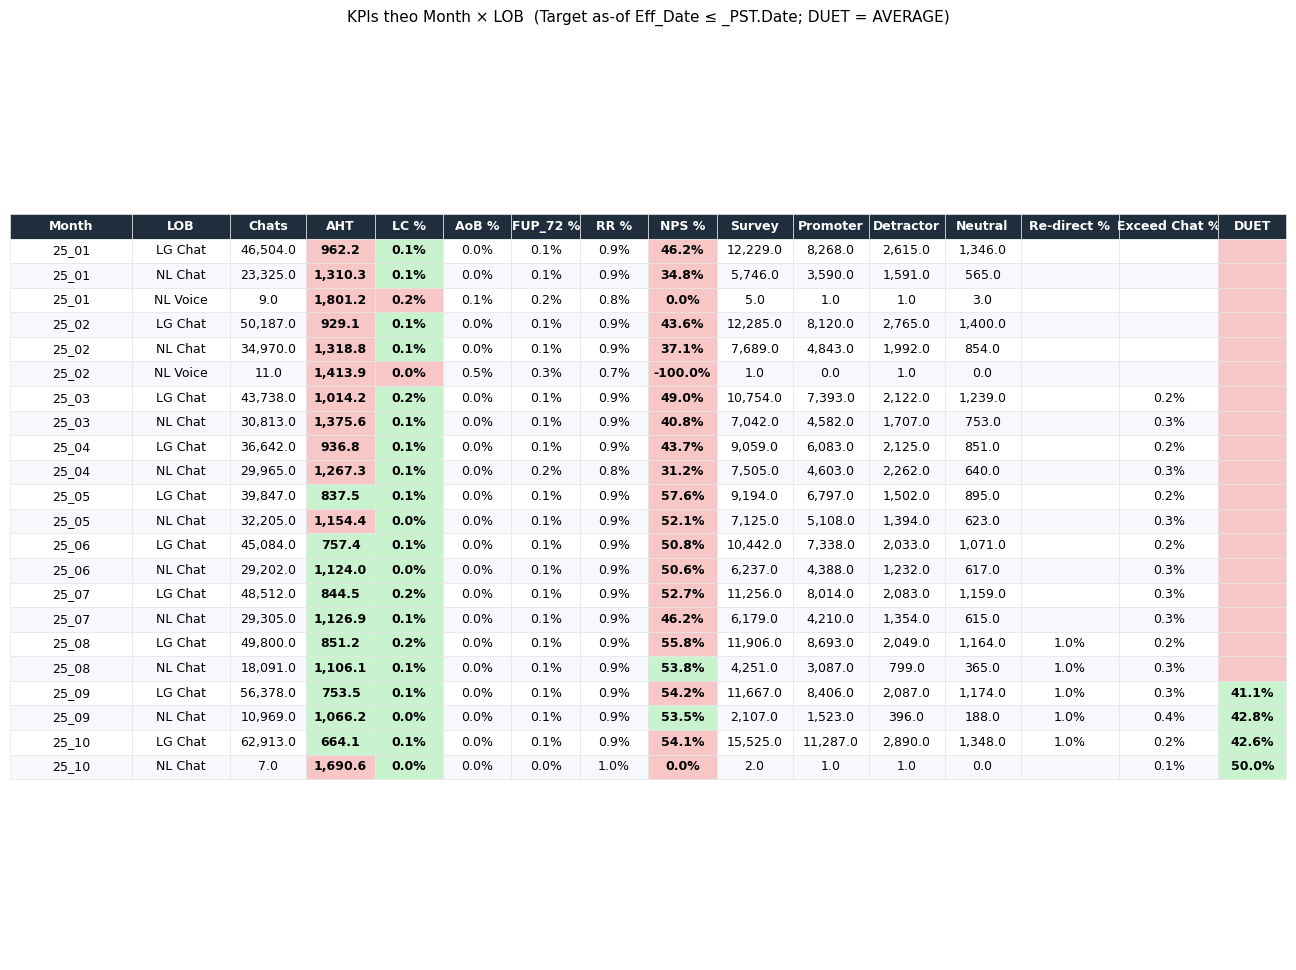

In [18]:
# Đọc parquet (chỉ cột cần thiết để nhẹ)
parquet_path = Path(r"C:\Users\huuchinh.nguyen\Concentrix Corporation\WFM-Expedia-HCM - Branding files\BI_Task\RAW\OUTPUT_PERFORMANCE\OUTPUT_PERFORMANCE_COMBINE\_performance_hcm.parquet")
needed_cols = [
    "_PST.Month","_PST.Date","LOB",
    "_conver_unique","Conversation Id",
    "Handle Time (Sum)","_lc","_aob","CCR72",
    "_survey","_promoter","_detractor","_neutral",
    "Re_Direct","Exceed Chat",
    "DUET","delight","usability","ease","trust"
]
df = pd.read_parquet(parquet_path, engine="pyarrow", columns=[c for c in needed_cols if c in pd.read_parquet(parquet_path, engine="pyarrow").columns])

# Khai báo target inline (NPS/LC/DUET nhập 0–1; AHT nhập theo đơn vị thực tế)
df_target = pd.DataFrame([
    {"Eff_Date":"2024-06-01","LOB":"NL Chat","Metric":"NPS","Target":0.53,"Weight":0.5},
    {"Eff_Date":"2024-06-01","LOB":"NL Chat","Metric":"LC", "Target":0.04,"Weight":0.2},
    {"Eff_Date":"2024-06-01","LOB":"NL Chat","Metric":"AHT","Target":1146,"Weight":0.3},
    {"Eff_Date":"2024-06-01","LOB":"NL Chat","Metric":"DUET","Target":0.52,"Weight":0.0},

    {"Eff_Date":"2024-06-01","LOB":"LG Chat","Metric":"NPS","Target":0.59,"Weight":0.5},
    {"Eff_Date":"2024-06-01","LOB":"LG Chat","Metric":"LC", "Target":0.04,"Weight":0.2},
    {"Eff_Date":"2024-06-01","LOB":"LG Chat","Metric":"AHT","Target":890, "Weight":0.3},
    {"Eff_Date":"2024-06-01","LOB":"LG Chat","Metric":"DUET","Target":0.58,"Weight":0.0},
])
df_target["Eff_Date"] = pd.to_datetime(df_target["Eff_Date"], errors="coerce")

fig = render_kpi_table(
    dataset=df,
    group_cols=["_PST.Month","LOB"],   # đổi linh động: ["_PST.Date","LOB"] / ["Region","Supervisor Name"] ...
    include_extra=True,                # để hiển thị & so target DUET
    decimals=1,
    target_df=df_target,               # bảng target inline
    target_date_col="Eff_Date"
)
plt.show()

In [ ]:
# import sys, importlib, matplotlib.pyplot as plt

# sys.path.insert(0, r"C:\Users\huuchinh.nguyen\Concentrix Corporation\WFM-Expedia-HCM - Branding files\BI_Task\CODE\Python_Code")

# import bi_visual
# importlib.reload(bi_visual)
# fig = bi_visual.render_kpi_table(dataset)
# plt.show()
